In [1]:
!unzip -q archive.zip

Çalışılan Cihaz: cuda
Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

--- VGG19 Modeli Yükleniyor ---
Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:04<00:00, 118MB/s]


Eğitim Başlıyor...
Epoch 1/10
Train Loss: 1.7364 Acc: 0.4326
Epoch 2/10
Train Loss: 1.6053 Acc: 0.4721
Epoch 3/10
Train Loss: 1.5617 Acc: 0.4784
Epoch 4/10
Train Loss: 1.5236 Acc: 0.4678
Epoch 5/10
Train Loss: 1.5121 Acc: 0.4891
Epoch 6/10
Train Loss: 1.4907 Acc: 0.4861
Epoch 7/10
Train Loss: 1.4854 Acc: 0.4893
Epoch 8/10
Train Loss: 1.4814 Acc: 0.4985
Epoch 9/10
Train Loss: 1.4626 Acc: 0.5053
Epoch 10/10
Train Loss: 1.4714 Acc: 0.5022


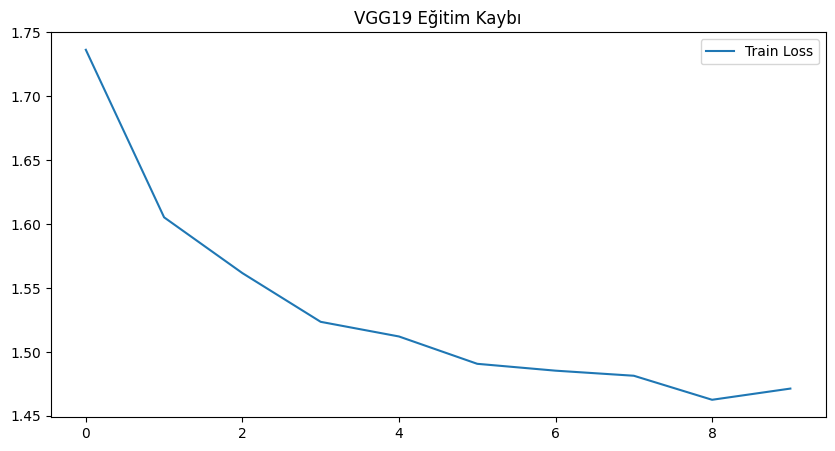

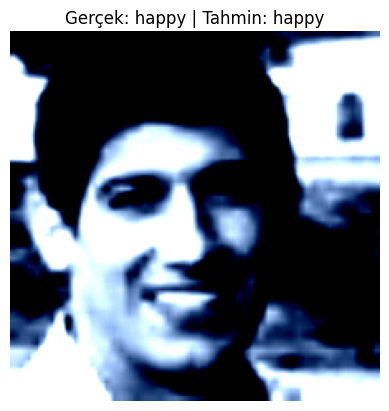


🎥 TESPİT EDİLEN DUYGU: HAPPY (Musical öneriliyor)
--------------------------------------------------
* PK (8.1) - Comedy, Drama, Musical
* My Fair Lady (7.8) - Drama, Family, Musical
* Duck Soup (7.8) - Comedy, Musical, War


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import pandas as pd
import os
import random
from PIL import Image

# 1. AYARLAR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Çalışılan Cihaz: {device}")

BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 10
NUM_CLASSES = 7
DATA_DIR = '.' 
IMDB_PATH = 'imdb_top_1000.csv' 

# 2. VERİ ÖN İŞLEME
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


if os.path.exists(DATA_DIR):
    image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                      for x in ['train', 'test']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True)
                   for x in ['train', 'test']}
    class_names = image_datasets['train'].classes
    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
    print(f"Sınıflar: {class_names}")
else:
    print("HATA: Veri klasörü bulunamadı!")

# 3. MODEL: VGG19 (Batch Norm)
print("\n--- VGG19 Modeli Yükleniyor ---")
model = models.vgg19_bn(weights=models.VGG19_BN_Weights.IMAGENET1K_V1)


for param in model.features.parameters():
    param.requires_grad = False


num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, NUM_CLASSES)
model = model.to(device)

# 4. EĞİTİM DÖNGÜSÜ
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)

train_loss_hist = []
val_acc_hist = []

print("Eğitim Başlıyor...")
for epoch in range(EPOCHS):
    print(f'Epoch {epoch+1}/{EPOCHS}')

    # Train
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / dataset_sizes['train']
    train_loss_hist.append(epoch_loss)

    # Validation
    model.eval()
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

    epoch_acc = running_corrects.double() / dataset_sizes['test']
    val_acc_hist.append(epoch_acc.item())

    print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')


plt.figure(figsize=(10,5))
plt.plot(train_loss_hist, label='Train Loss')
plt.title('VGG19 Eğitim Kaybı')
plt.legend()
plt.show()


def recommend_movies(emotion):
    
    genre_map = {
        'angry': 'Action',     
        'disgust': 'Horror',    
        'fear': 'Comedy',       
        'happy': 'Musical',     
        'neutral': 'Documentary', 
        'sad': 'Drama',         
        'surprise': 'Sci-Fi'    
    }

    target_genre = genre_map.get(emotion, 'Drama')

    
    if os.path.exists(IMDB_PATH):
        df = pd.read_csv(IMDB_PATH)
        
        filtered = df[df['Genre'].str.contains(target_genre, case=False, na=False)]

        if not filtered.empty:
            suggestions = filtered.sample(n=min(3, len(filtered)))[['Series_Title', 'Genre', 'Overview', 'IMDB_Rating']]
            print(f"\n🎥 TESPİT EDİLEN DUYGU: {emotion.upper()} ({target_genre} öneriliyor)")
            print("-" * 50)
            for idx, row in suggestions.iterrows():
                print(f"* {row['Series_Title']} ({row['IMDB_Rating']}) - {row['Genre']}")
        else:
            print("Bu türde film bulunamadı.")
    else:
        print("IMDB CSV dosyası bulunamadı!")


model.eval()
test_images, test_labels = next(iter(dataloaders['test']))
img = test_images[0].to(device)
label = class_names[test_labels[0]]

with torch.no_grad():
    output = model(img.unsqueeze(0)) 
    _, pred = torch.max(output, 1)
    pred_emotion = class_names[pred.item()]


plt.imshow(test_images[0].permute(1, 2, 0)) 
plt.title(f"Gerçek: {label} | Tahmin: {pred_emotion}")
plt.axis('off')
plt.show()


recommend_movies(pred_emotion)


>>> KİLİTLER AÇILIYOR: Fine-Tuning Başlıyor... <<<
Modelin tüm katmanları eğitime açılıyor ve öğrenme hızı düşürülüyor.
Hedef: %60 ve üzeri başarı!
------------------------------
Fine-Tune Epoch 1/10
Train Loss: 1.3143 | Validation Acc: 0.5688
Fine-Tune Epoch 2/10
Train Loss: 1.1276 | Validation Acc: 0.5906
Fine-Tune Epoch 3/10
Train Loss: 1.0427 | Validation Acc: 0.6215
Fine-Tune Epoch 4/10
Train Loss: 0.9682 | Validation Acc: 0.6354
Fine-Tune Epoch 5/10
Train Loss: 0.9137 | Validation Acc: 0.6463
Fine-Tune Epoch 6/10
Train Loss: 0.8581 | Validation Acc: 0.6637
Fine-Tune Epoch 7/10
Train Loss: 0.8088 | Validation Acc: 0.6594
Fine-Tune Epoch 8/10
Train Loss: 0.7602 | Validation Acc: 0.6698
Fine-Tune Epoch 9/10
Train Loss: 0.7115 | Validation Acc: 0.6622
Fine-Tune Epoch 10/10
Train Loss: 0.6659 | Validation Acc: 0.6751

FINE-TUNING TAMAMLANDI!
Eski Başarı: %50 civarı
Yeni Başarı: %67.51


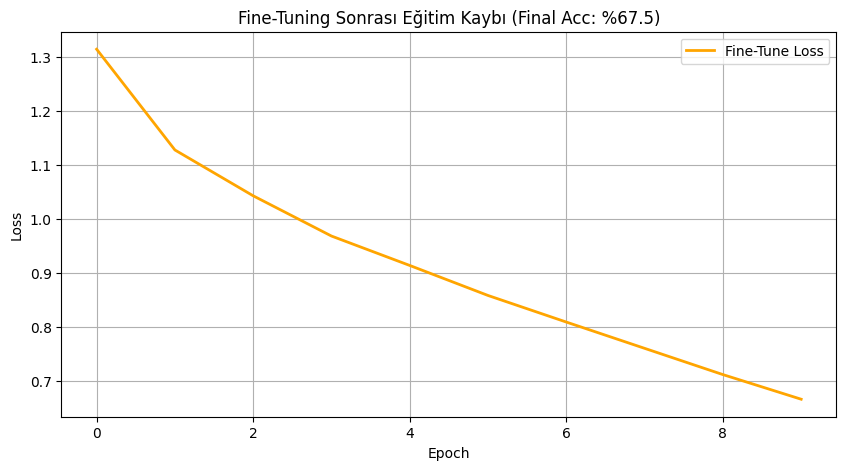

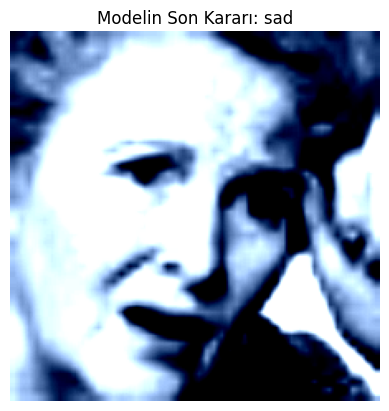


🎥 TESPİT EDİLEN DUYGU: SAD (Drama öneriliyor)
--------------------------------------------------
* Kramer vs. Kramer (7.8) - Drama
* Casino (8.2) - Crime, Drama
* Spotlight (8.1) - Biography, Crime, Drama


In [ ]:
# --- BÖLÜM 2: FINE-TUNING  ---
import torch.optim as optim

print("\n>>> KİLİTLER AÇILIYOR: Fine-Tuning Başlıyor... <<<")
print("Modelin tüm katmanları eğitime açılıyor ve öğrenme hızı düşürülüyor.")

for param in model.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(model.parameters(), lr=0.0001)


FINE_TUNE_EPOCHS = 10 
ft_loss_hist = []
ft_acc_hist = []

print(f"Hedef: %60 ve üzeri başarı!")
print("-" * 30)

for epoch in range(FINE_TUNE_EPOCHS):
    print(f'Fine-Tune Epoch {epoch+1}/{FINE_TUNE_EPOCHS}')

    # --- TRAIN (Eğitim) ---
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_ft.zero_grad()      
        outputs = model(inputs)       
        loss = criterion(outputs, labels) 
        loss.backward()               
        optimizer_ft.step()           

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / dataset_sizes['train']
    ft_loss_hist.append(epoch_loss)

    # --- VALIDATION (Test) ---
    model.eval() 
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

    epoch_acc = running_corrects.double() / dataset_sizes['test']
    ft_acc_hist.append(epoch_acc.item())

    
    print(f'Train Loss: {epoch_loss:.4f} | Validation Acc: {epoch_acc:.4f}')


final_acc = ft_acc_hist[-1] * 100
print("\n" + "="*40)
print(f"FINE-TUNING TAMAMLANDI!")
print(f"Eski Başarı: %50 civarı")
print(f"Yeni Başarı: %{final_acc:.2f}")
print("="*40)


plt.figure(figsize=(10,5))
plt.plot(ft_loss_hist, label='Fine-Tune Loss', color='orange', linewidth=2)
plt.title(f'Fine-Tuning Sonrası Eğitim Kaybı (Final Acc: %{final_acc:.1f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


model.eval()
test_images, test_labels = next(iter(dataloaders['test']))
img = test_images[0].to(device)
with torch.no_grad():
    output = model(img.unsqueeze(0))
    _, pred = torch.max(output, 1)
    pred_emotion = class_names[pred.item()]

plt.imshow(test_images[0].permute(1, 2, 0))
plt.title(f"Modelin Son Kararı: {pred_emotion}")
plt.axis('off')
plt.show()


try:
    recommend_movies(pred_emotion)
except:
    pass

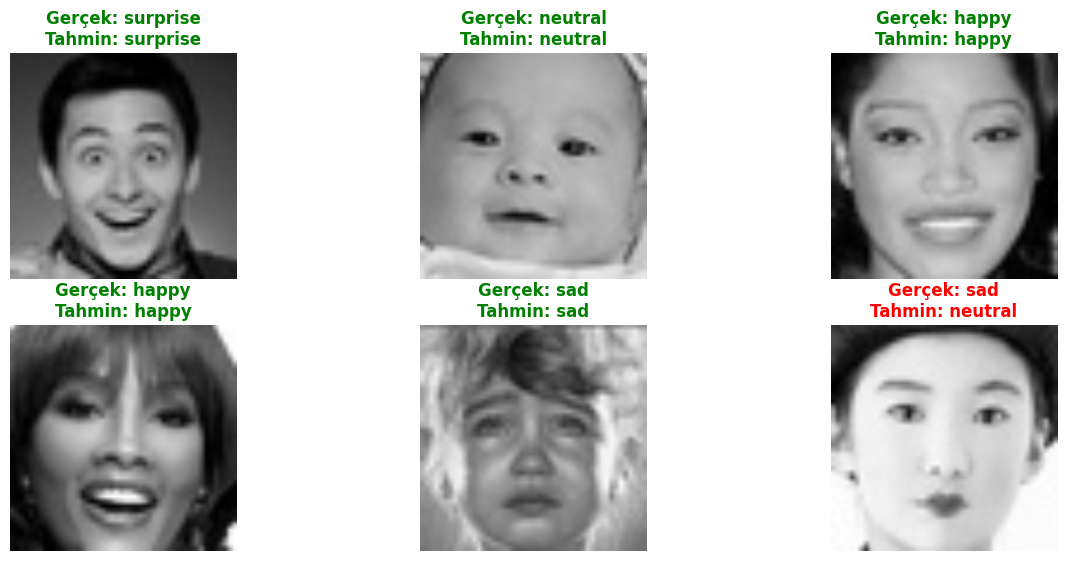

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def visualize_model_predictions(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//3 + 1, 3, images_so_far)
                ax.axis('off')

                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                ax.imshow(img)

                
                true_label = class_names[labels[j]]
                pred_label = class_names[preds[j]]
                color = 'green' if true_label == pred_label else 'red'

                ax.set_title(f'Gerçek: {true_label}\nTahmin: {pred_label}', color=color, fontsize=12, fontweight='bold')

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


visualize_model_predictions(model)

In [ ]:
import torch
from google.colab import files

torch.save(model.state_dict(), 'vgg19_duygu_modeli_acc67.pth')
print("✅ Model dosyası oluşturuldu! İndirme hazırlanıyor...")

files.download('vgg19_duygu_modeli_acc67.pth')

✅ Model dosyası oluşturuldu! İndirme hazırlanıyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
from torchvision import models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg19_bn(weights=None)
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 7)
model = model.to(device)

print("✅ Boş model iskeleti hazır.")

✅ Boş model iskeleti hazır.


In [ ]:
# 1. Model ağırlıklarını (beynini) yükle
model_yolu = 'vgg19_duygu_modeli_acc67.pth' 
model.load_state_dict(torch.load(model_yolu, map_location=device))
model.eval()
print("🚀 Model ağırlıkları başarıyla yüklendi!")


train_loss_hist = [1.3143, 1.1276, 1.0427, 0.9682, 0.9137, 0.8581, 0.8088, 0.7602, 0.7115, 0.6659]
val_acc_hist = [0.5688, 0.5906, 0.6215, 0.6354, 0.6463, 0.6637, 0.6594, 0.6698, 0.6622, 0.6751]

print("📊 Başarı listeleri manuel olarak güncellendi.")

🚀 Model ağırlıkları başarıyla yüklendi!
📊 Başarı listeleri manuel olarak güncellendi.


In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


DATA_DIR = '.'
BATCH_SIZE = 32


data_transforms = {
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


if os.path.exists(os.path.join(DATA_DIR, 'test')):
    image_datasets = {'test': datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), data_transforms['test'])}
    dataloaders = {'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False)}
    class_names = image_datasets['test'].classes
    print(f"✅ Test verileri başarıyla yüklendi! Sınıflar: {class_names}")
    print(f"📊 Toplam Test Resmi: {len(image_datasets['test'])}")
else:
    print("❌ HATA: 'test' klasörü bulunamadı. Lütfen 'unzip' işleminin bittiğinden emin ol!")

✅ Test verileri başarıyla yüklendi! Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
📊 Toplam Test Resmi: 7178


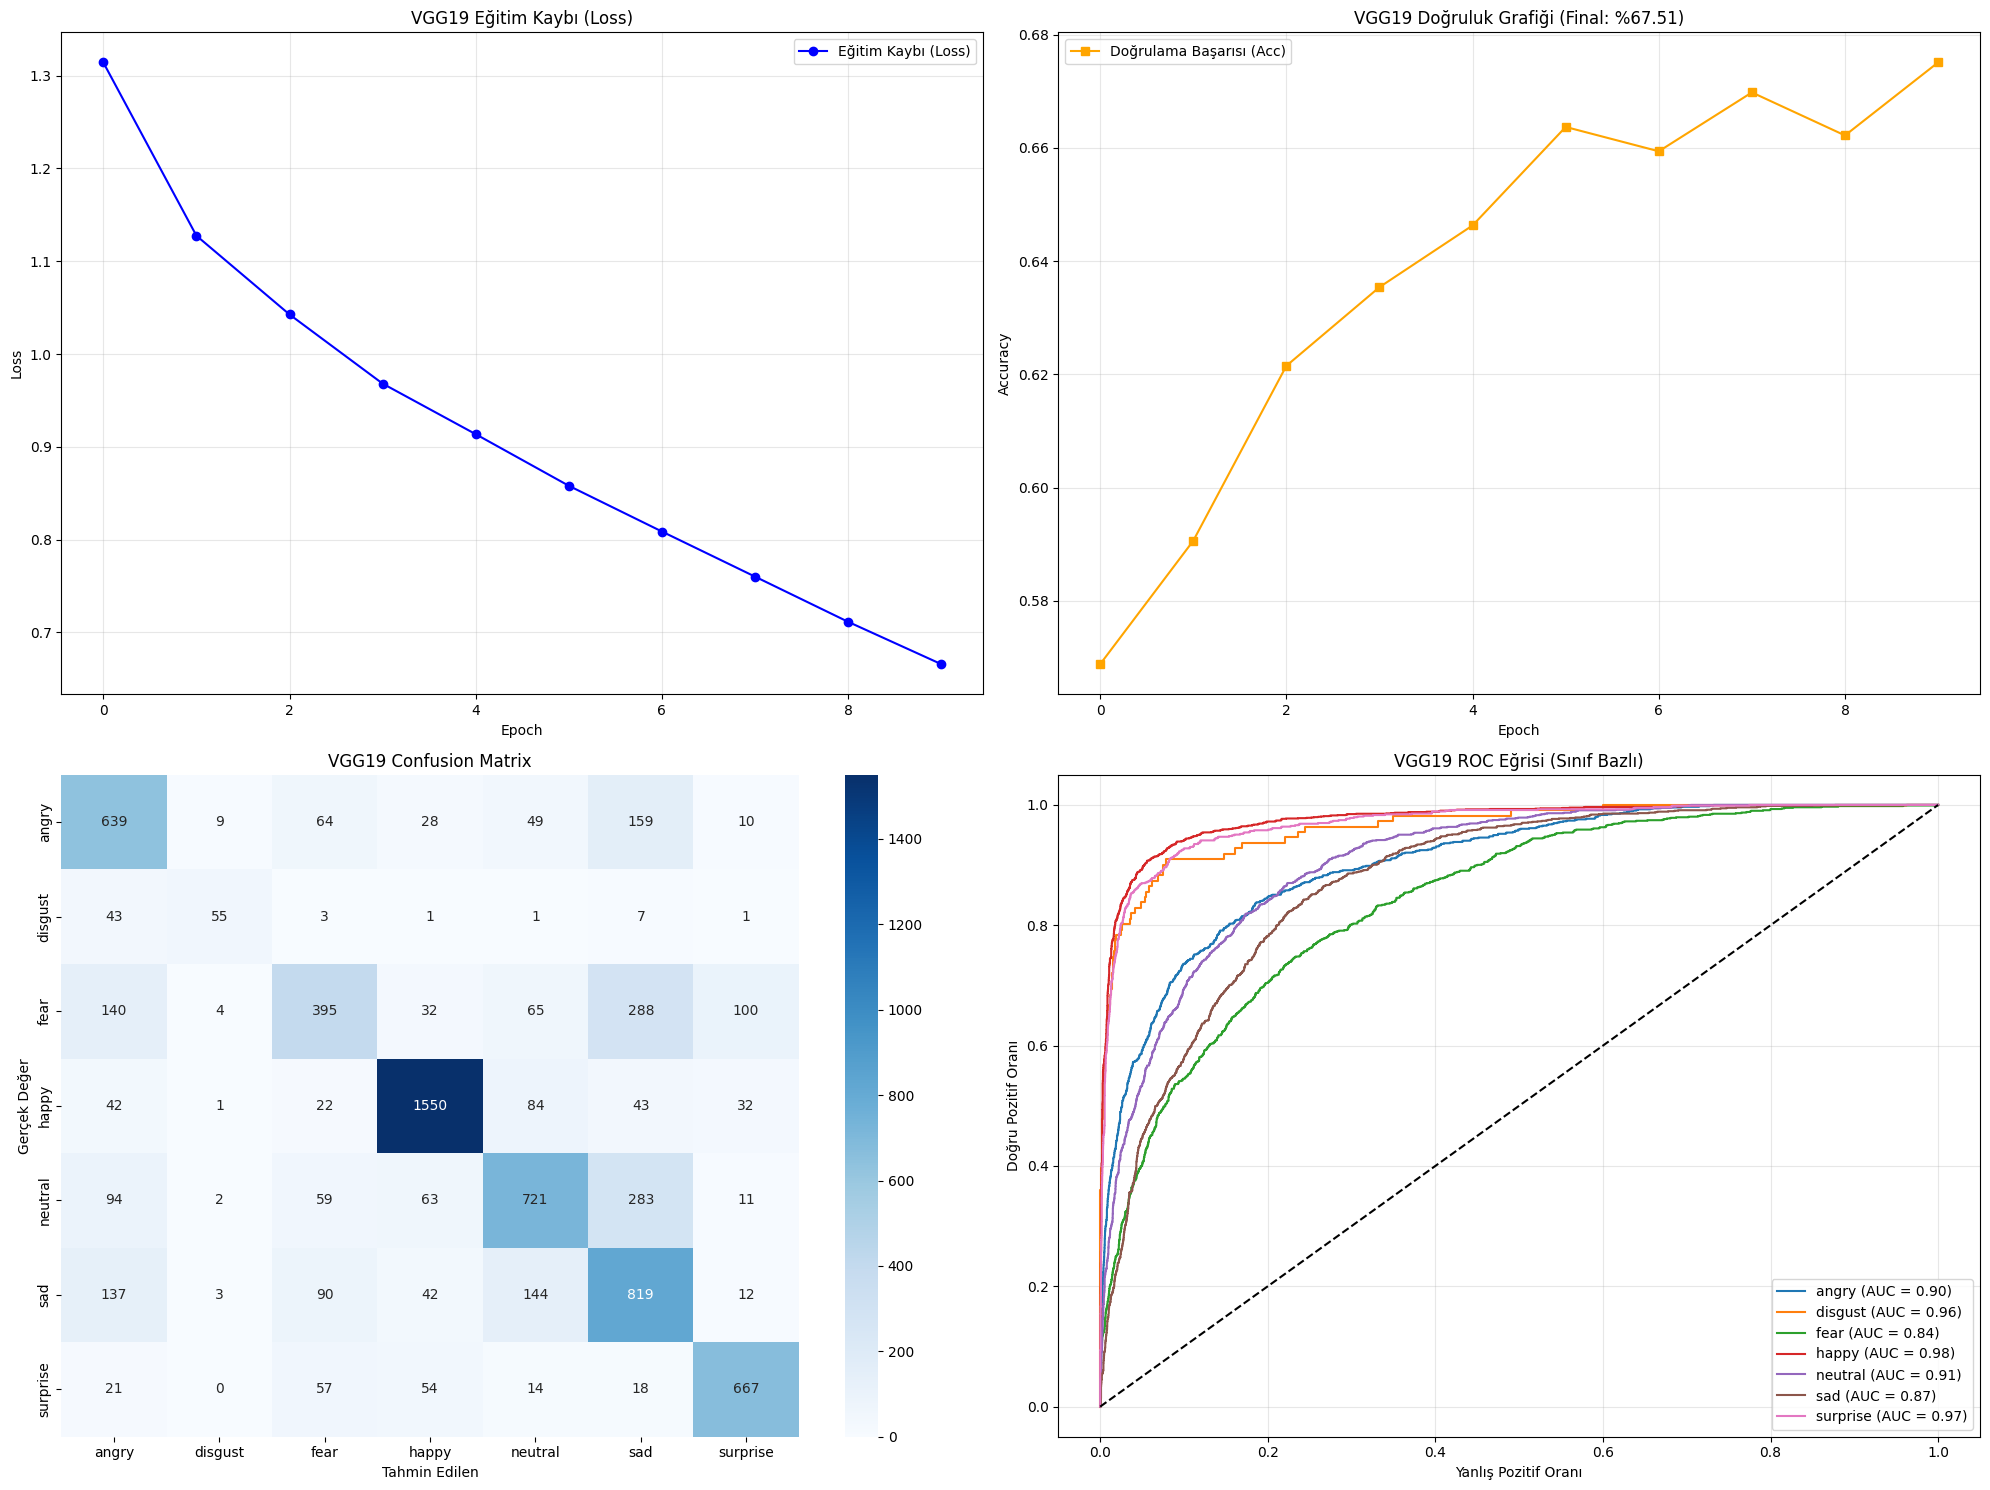

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np


train_loss_hist = [1.3143, 1.1276, 1.0427, 0.9682, 0.9137, 0.8581, 0.8088, 0.7602, 0.7115, 0.6659]
val_acc_hist = [0.5688, 0.5906, 0.6215, 0.6354, 0.6463, 0.6637, 0.6594, 0.6698, 0.6622, 0.6751]


plt.figure(figsize=(20, 15))


plt.subplot(2, 2, 1)
plt.plot(train_loss_hist, label='Eğitim Kaybı (Loss)', color='blue', marker='o')
plt.title('VGG19 Eğitim Kaybı (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(val_acc_hist, label='Doğrulama Başarısı (Acc)', color='orange', marker='s')
plt.title(f'VGG19 Doğruluk Grafiği (Final: %{val_acc_hist[-1]*100:.2f})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)


all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.subplot(2, 2, 3)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('VGG19 Confusion Matrix')


y_test_bin = label_binarize(all_labels, classes=range(7))

all_probs = []
with torch.no_grad():
    for inputs, _ in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = torch.softmax(model(inputs), dim=1)
        all_probs.extend(outputs.cpu().numpy())
all_probs = np.array(all_probs)

plt.subplot(2, 2, 4)
for i in range(7):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.title('VGG19 ROC Eğrisi (Sınıf Bazlı)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()